In [ ]:
import torch
from diffusers import StableDiffusionPipeline
import matplotlib.pyplot as plt

In [ ]:
from huggingface_hub import login
import os
login(os.getenv("HF_TOKEN"))  # Paste your token here

In [7]:
# Load pipeline
device = "cuda" if torch.cuda.is_available() else "cpu"

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
    use_safetensors=True
).to(device)

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

safety_checker/model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

In [10]:
# ---- User only enters prompt ----
prompt = input("Enter your prompt: ")

# ---- Default values ----
negative_prompt = "low quality, blurry, distorted, extra fingers, bad anatomy, watermark"
height = 512
width = 512
steps = 30
guidance = 7.5
generator = torch.Generator(device)  # random seed each time

  0%|          | 0/30 [00:00<?, ?it/s]

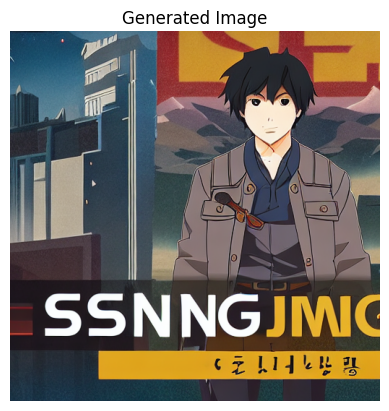

In [11]:
# ---- Generate Image ----
image = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    height=height,
    width=width,
    num_inference_steps=steps,
    guidance_scale=guidance,
    generator=generator
).images[0]

# ---- Display ----
plt.imshow(image)
plt.axis("off")
plt.title("Generated Image")
plt.show()